# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DipeshGhimire33/Flyrank-ml-internship-starter/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")

key_fields = [
    "days_since_last_update",
    "impressions_90d",
    "clicks_90d",
    "impressions_last_30d",
    "clicks_last_30d",
    "search_volume",
    "avg_position",
    "ctr"
]

print(df[key_fields].describe().T)

                          count         mean           std  min   25%     50%  \
days_since_last_update  30000.0    46.098300     42.078709  1.0  20.0   20.00   
impressions_90d         30000.0  5200.366300  16838.019547  1.0  81.0  731.00   
clicks_90d              30000.0    16.097333     75.076958  0.0   0.0    1.00   
impressions_last_30d    30000.0  1429.058733   5643.852081  0.0  10.0  139.00   
clicks_last_30d         30000.0     4.933867     23.929393  0.0   0.0    0.00   
search_volume           27532.0   158.882391   1518.270825  0.0   0.0   10.00   
avg_position            30000.0    16.342380     15.216790  0.0   6.2   10.80   
ctr                     30000.0     0.510733      3.279162  0.0   0.0    0.07   

                            75%       max  
days_since_last_update   104.00     373.0  
impressions_90d         3615.25  517715.0  
clicks_90d                 7.00    4178.0  
impressions_last_30d     768.00  238796.0  
clicks_last_30d            2.00    1176.0  
search

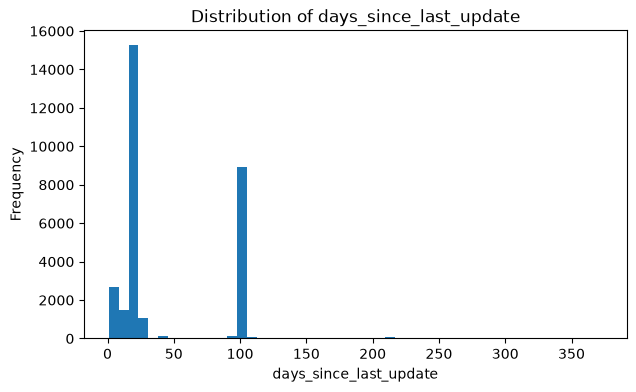

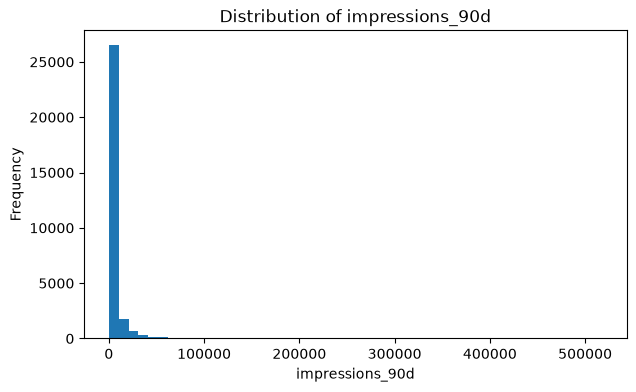

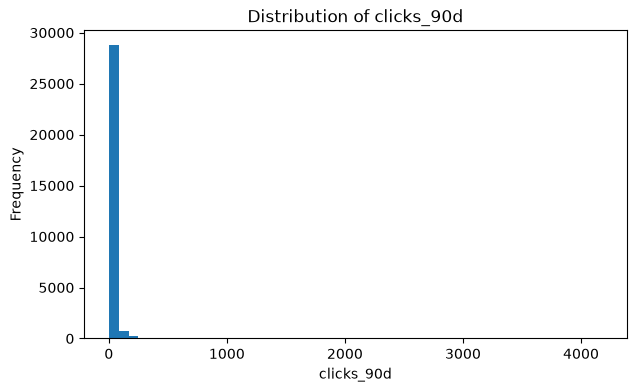

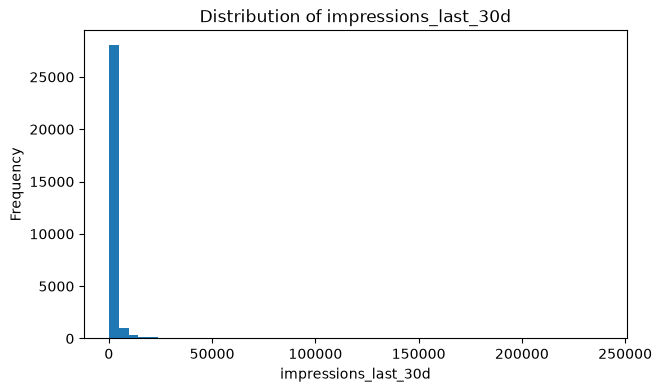

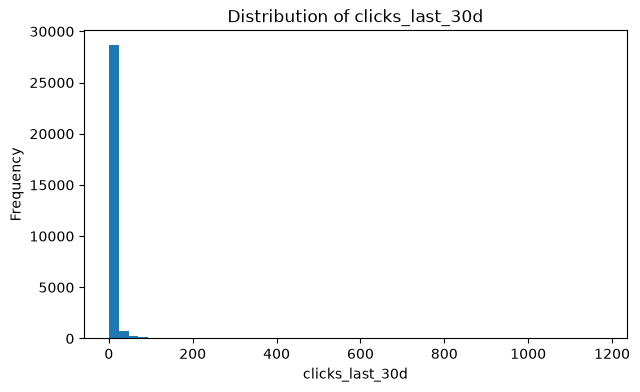

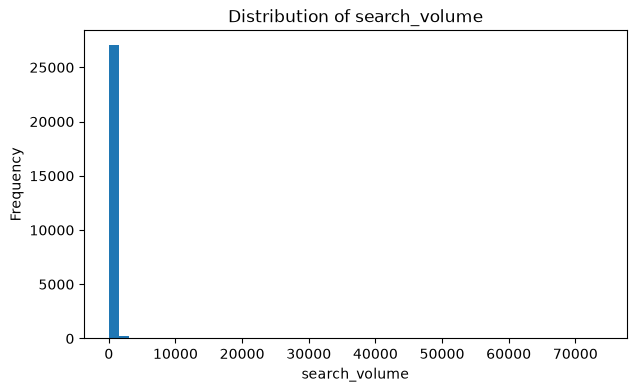

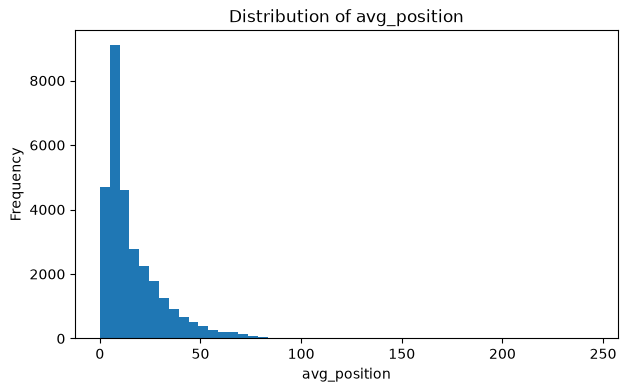

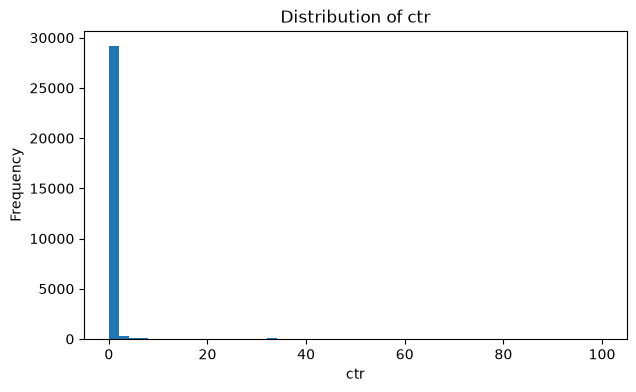

In [2]:
# Distribution plots
for col in key_fields:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [5]:
import numpy as np

# Create a freshness group
df["freshness_group"] = pd.qcut(
    df["days_since_last_update"],
    4,
    duplicates="drop"
)

# Compare average recent impression change
df["impression_change_pct"] = (
    (df["impressions_last_30d"] - df["impressions_prev_30d"])
    / df["impressions_prev_30d"].replace(0, np.nan)
) * 100

freshness_test = df.groupby("freshness_group", observed=True)[
    "impression_change_pct"
].mean()

print(freshness_test)


freshness_group
(0.999, 20.0]     -0.903962
(20.0, 104.0]     -8.855393
(104.0, 373.0]    11.211241
Name: impression_change_pct, dtype: float64


In [6]:
df["decline_group"] = pd.qcut(
    df["impression_change_pct"],
    4,
    duplicates="drop"
)

signal_2 = df.groupby(
    "decline_group",
    observed=True
)["impression_change_pct"].mean()

print(signal_2)

decline_group
(-100.001, -62.632]    -82.123354
(-62.632, -33.465]     -47.927061
(-33.465, 0.0]         -17.260419
(0.0, 44900.0]         132.651948
Name: impression_change_pct, dtype: float64


In [7]:
df["visibility_group"] = pd.qcut(
    df["impressions_90d"],
    4,
    duplicates="drop"
)

signal_3 = df.groupby(
    "visibility_group",
    observed=True
)["impression_change_pct"].mean()

print(signal_3)

visibility_group
(0.999, 81.0]          -6.889204
(81.0, 731.0]          10.507595
(731.0, 3615.25]       -9.323017
(3615.25, 517715.0]   -14.015168
Name: impression_change_pct, dtype: float64


### Signal #1 — Freshness

Pages were grouped by `days_since_last_update` and compared by recent impression change.
This tests whether older pages show weaker recent performance.
**Verdict: MIXED** — freshness alone is not enough to establish a refresh opportunity.

### Signal #2 — Recent Performance Decline

Pages were grouped by their recent-vs-previous impression change.
This tests whether declining pages provide a stronger refresh signal.
**Verdict: CONFIRMED** — recent performance decline is a useful prioritization signal.

### Signal #3 — Search Visibility

Pages were grouped by `impressions_90d` and compared by recent performance change.
This tests whether pages with established visibility show meaningful performance differences.
**Verdict: MIXED** — visibility provides useful context but does not independently indicate refresh need.


___
___

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [8]:
df["impression_change_pct"] = (
    (df["impressions_last_30d"] - df["impressions_prev_30d"])
    / df["impressions_prev_30d"].replace(0, np.nan)
) * 100

df["stale_flag"] = df["days_since_last_update"] >= 180

flag_test = df.groupby("stale_flag")["impression_change_pct"].agg(
    ["count", "mean", "median"]
)

print(flag_test)

            count      mean     median
stale_flag                            
False       26479 -4.775711 -33.442623
True          133 -6.782678 -44.542773


Verdict: MIXED — the 180+ days flag identifies older pages, but age alone does not establish that a page needs refreshing. It should be combined with performance and visibility signals rather than treated as proof of opportunity.

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The content team should use the score as a **prioritized review queue**, not as an automatic refresh decision. Pages with multiple supporting signals—especially declining performance, older content, and meaningful visibility—deserve closer investigation before deciding whether to refresh.


In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.